# Feature Comparison — Hazard Ratios (Cox PH)

> **Prerequisite:** Run `clean_data.ipynb` first. This notebook reads from `cleaned_data/mm_pgs.csv`.

Fits a Cox Proportional Hazards model and compares the hazard ratios of all selected features to assess their relative impact on the risk of developing multiple myeloma.

`lifelines` is used here instead of `scikit-survival` because it exposes analytical standard errors and 95% confidence intervals directly from the fitted model — required for a proper forest plot.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lifelines import CoxPHFitter

## Load cleaned data

In [2]:
data_path = Path('cleaned_data/mm_pgs.csv')
assert data_path.exists(), (
    "cleaned_data/myeloma_cleaned.csv not found — run clean_data.ipynb first."
)

df = pd.read_csv(data_path, index_col='ID')
print(f'Loaded {len(df)} rows')
df.head()

Loaded 2000 rows


,ancestry,age,m_spike,sflc_ratio,creatinine,pgs_score,status,time_years
ID,,,,,,,,
1,1,0.137747,2.422286,-0.287442,-1.718453,0.012128,1,1.335000
2,1,0.652230,2.640049,-0.247821,0.424321,1.002874,1,0.066667
3,1,-0.033230,-0.725654,-0.319304,-0.646363,0.732567,0,8.948333
4,1,0.498547,0.015844,0.057345,0.067536,0.829773,1,4.296667
5,1,-0.346698,1.190935,-0.568467,0.213709,-0.778696,0,3.765000


## Fit Cox PH model

In [3]:
feature_cols = ['ancestry', 'age', 'm_spike', 'sflc_ratio', 'creatinine', 'pgs_score']
cols = feature_cols + ['time_years', 'status']

cox = CoxPHFitter()
cox.fit(df[cols], duration_col='time_years', event_col='status')

print(f'Concordance index: {cox.concordance_index_:.4f}')
cox.print_summary()

Concordance index: 0.7080


<lifelines.CoxPHFitter: fitted with 2000 total observations, 1481 right-censored observations>
             duration col = 'time_years'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 2000
number of events observed = 519
   partial log-likelihood = -3561.15
         time fit was run = 2026-03-03 10:35:51 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ancestry   -0.02      0.98      0.11           -0.24            0.20                0.79                1.22
age         0.16      1.17      0.04            0.07            0.25                1.08                1.28
m_spike     0.59      1.81      0.04            0.52            0.67                1.68                1.95
sflc_ratio  0.14      1.15      0.02            0.10            0.18                1.11                1.20
creatinine  0.12      1.13      0.04            0.04            0.20                1.04                1.22
pgs_score   0.36      1.43      0.04            0.28            0.44                1.32                1.56

            cmp to     z      p  -log2(p)
covariate                                
ancestry      0.00 -0.18   0.86      0.22
age           0.00  3.61 <0.005     11.69
m_spike       0.00 15.97 <0.005    188.23
sflc_ratio    0.00  6.86 <0.005     37.11
creatinine    0.00  2.85 <0.005      7.84
pgs_score     0.00  8.39 <0.005     54.18
---
Concordance = 0.71
Partial AIC = 7134.29
log-likelihood ratio test = 304.55 on 6 df
-log2(p) of ll-ratio test = 206.17

## Extract hazard ratios and 95% CIs

Each coefficient is the log-hazard ratio for a **1 standard deviation increase** in that feature (features were standardized in `clean_data.ipynb`), so HRs are directly comparable across features.

- **HR > 1** — higher values associated with increased risk  
- **HR < 1** — higher values associated with decreased risk

In [4]:
s = cox.summary

summary = pd.DataFrame({
    'HR':       s['exp(coef)'],
    'CI_lower': s['exp(coef) lower 95%'],
    'CI_upper': s['exp(coef) upper 95%'],
    'p':        s['p'],
}).sort_values('HR', ascending=True)   # ascending=True so highest HR is at the top when plotted

summary

,HR,CI_lower,CI_upper,p
covariate,,,,
ancestry,0.980469,0.788999,1.218404,8.587743e-01
creatinine,1.127471,1.038202,1.224416,4.361399e-03
sflc_ratio,1.153941,1.107706,1.202106,6.752388e-12
age,1.173721,1.076047,1.280261,3.022837e-04
pgs_score,1.434022,1.318194,1.560029,4.900545e-17
m_spike,1.809807,1.682704,1.946511,2.169185e-57


## Forest plot

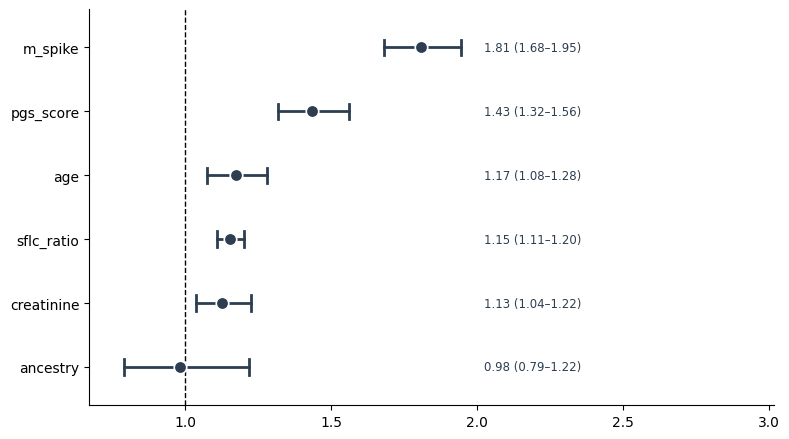

In [5]:

COLOR = '#2c3e50'

fig, ax = plt.subplots(figsize=(8, 4.5))

y_pos    = np.arange(len(summary))
features = summary.index.tolist()
hrs      = summary['HR'].values
ci_lower = summary['CI_lower'].values
ci_upper = summary['CI_upper'].values

for i, (hr, lo, hi) in enumerate(zip(hrs, ci_lower, ci_upper)):
    ax.plot([lo, hi], [i, i], color=COLOR, linewidth=2, zorder=2)
    ax.plot([lo, lo], [i - 0.12, i + 0.12], color=COLOR, linewidth=2, zorder=2)
    ax.plot([hi, hi], [i - 0.12, i + 0.12], color=COLOR, linewidth=2, zorder=2)
    ax.plot(hr, i, 'o', color=COLOR, markersize=9, zorder=3,
            markeredgecolor='white', markeredgewidth=1.2)
    ax.text(
        ci_upper.max() * 1.04, i,
        f'{hr:.2f} ({lo:.2f}–{hi:.2f})',
        va='center', ha='left', fontsize=8.5, color=COLOR
    )

ax.axvline(x=1, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(features, fontsize=10)
ax.set_xlim(ci_lower.min() * 0.85, ci_upper.max() * 1.55)
ax.set_ylim(-0.6, len(summary) - 0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("img/feature_comparison.svg")
plt.show()


## Rank features by absolute effect size

In [6]:
ranking = summary.copy()
ranking['abs_log_HR'] = np.log(ranking['HR']).abs()
ranking = ranking.sort_values('abs_log_HR', ascending=False)
ranking[['HR', 'CI_lower', 'CI_upper', 'p', 'abs_log_HR']]

,HR,CI_lower,CI_upper,p,abs_log_HR
covariate,,,,,
m_spike,1.809807,1.682704,1.946511,2.169185e-57,0.593220
pgs_score,1.434022,1.318194,1.560029,4.900545e-17,0.360483
age,1.173721,1.076047,1.280261,3.022837e-04,0.160179
sflc_ratio,1.153941,1.107706,1.202106,6.752388e-12,0.143183
creatinine,1.127471,1.038202,1.224416,4.361399e-03,0.119977
ancestry,0.980469,0.788999,1.218404,8.587743e-01,0.019724
